In [5]:
# Import Library    
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import missingno as msno # visualize missing data parterns, msno.heatmap()

In [6]:
path = 'data/insurance_dataset.csv'

df = pd.read_csv(path)

df.columns = df.columns.str.lower().str.replace(' ', '_')

df.head()

,age,gender,annual_income,marital_status,number_of_dependents,education_level,occupation,health_score,location,policy_type,previous_claims,vehicle_age,credit_score,insurance_duration,premium_amount,policy_start_date,customer_feedback,smoking_status,exercise_frequency,property_type
0,56.0,Male,99990.0,Married,1.0,Master's,NaN,31.074627,Urban,Comprehensive,NaN,13,320.0,5,308.0,2022-12-10 15:21:39.078837,Poor,Yes,Daily,Condo
1,46.0,Male,2867.0,Single,1.0,Bachelor's,NaN,50.271335,Urban,Comprehensive,NaN,3,694.0,4,517.0,2023-01-31 15:21:39.078837,Good,Yes,Monthly,House
2,32.0,Female,30154.0,Divorced,3.0,Bachelor's,NaN,14.714909,Suburban,Comprehensive,2.0,16,652.0,8,849.0,2023-11-26 15:21:39.078837,Poor,No,Monthly,House
3,60.0,Female,48371.0,Divorced,0.0,PhD,Self-Employed,25.346926,Rural,Comprehensive,1.0,11,330.0,7,927.0,2023-02-27 15:21:39.078837,Poor,No,Rarely,Condo
4,25.0,Female,54174.0,Divorced,0.0,High School,Self-Employed,6.659499,Urban,Comprehensive,NaN,9,NaN,8,303.0,2020-11-25 15:21:39.078837,Poor,No,Rarely,Condo


In [7]:
df.dtypes

age                     float64
gender                      str
annual_income           float64
marital_status              str
number_of_dependents    float64
education_level             str
occupation                  str
health_score            float64
location                    str
policy_type                 str
previous_claims         float64
vehicle_age               int64
credit_score            float64
insurance_duration        int64
premium_amount          float64
policy_start_date           str
customer_feedback           str
smoking_status              str
exercise_frequency          str
property_type               str
dtype: object

In [8]:
df['policy_start_date'] = pd.to_datetime(df['policy_start_date'])

In [9]:
# Extract all catgorical variables 
categorical = df.select_dtypes(include=['object', 'str']).columns.tolist()

# Extract all numerical variables
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical.remove('premium_amount') # target 

In [10]:
numerical
categorical

['gender',
 'marital_status',
 'education_level',
 'occupation',
 'location',
 'policy_type',
 'customer_feedback',
 'smoking_status',
 'exercise_frequency',
 'property_type']

In [11]:
a = df['gender'].value_counts()
a.index.astype(str)
print(a)

df['gender'].dropna().value_counts()

gender
Male      139754
Female    139106
Name: count, dtype: int64


gender
Male      139754
Female    139106
Name: count, dtype: int64

**Distribution Analysis of Categorical Variables**

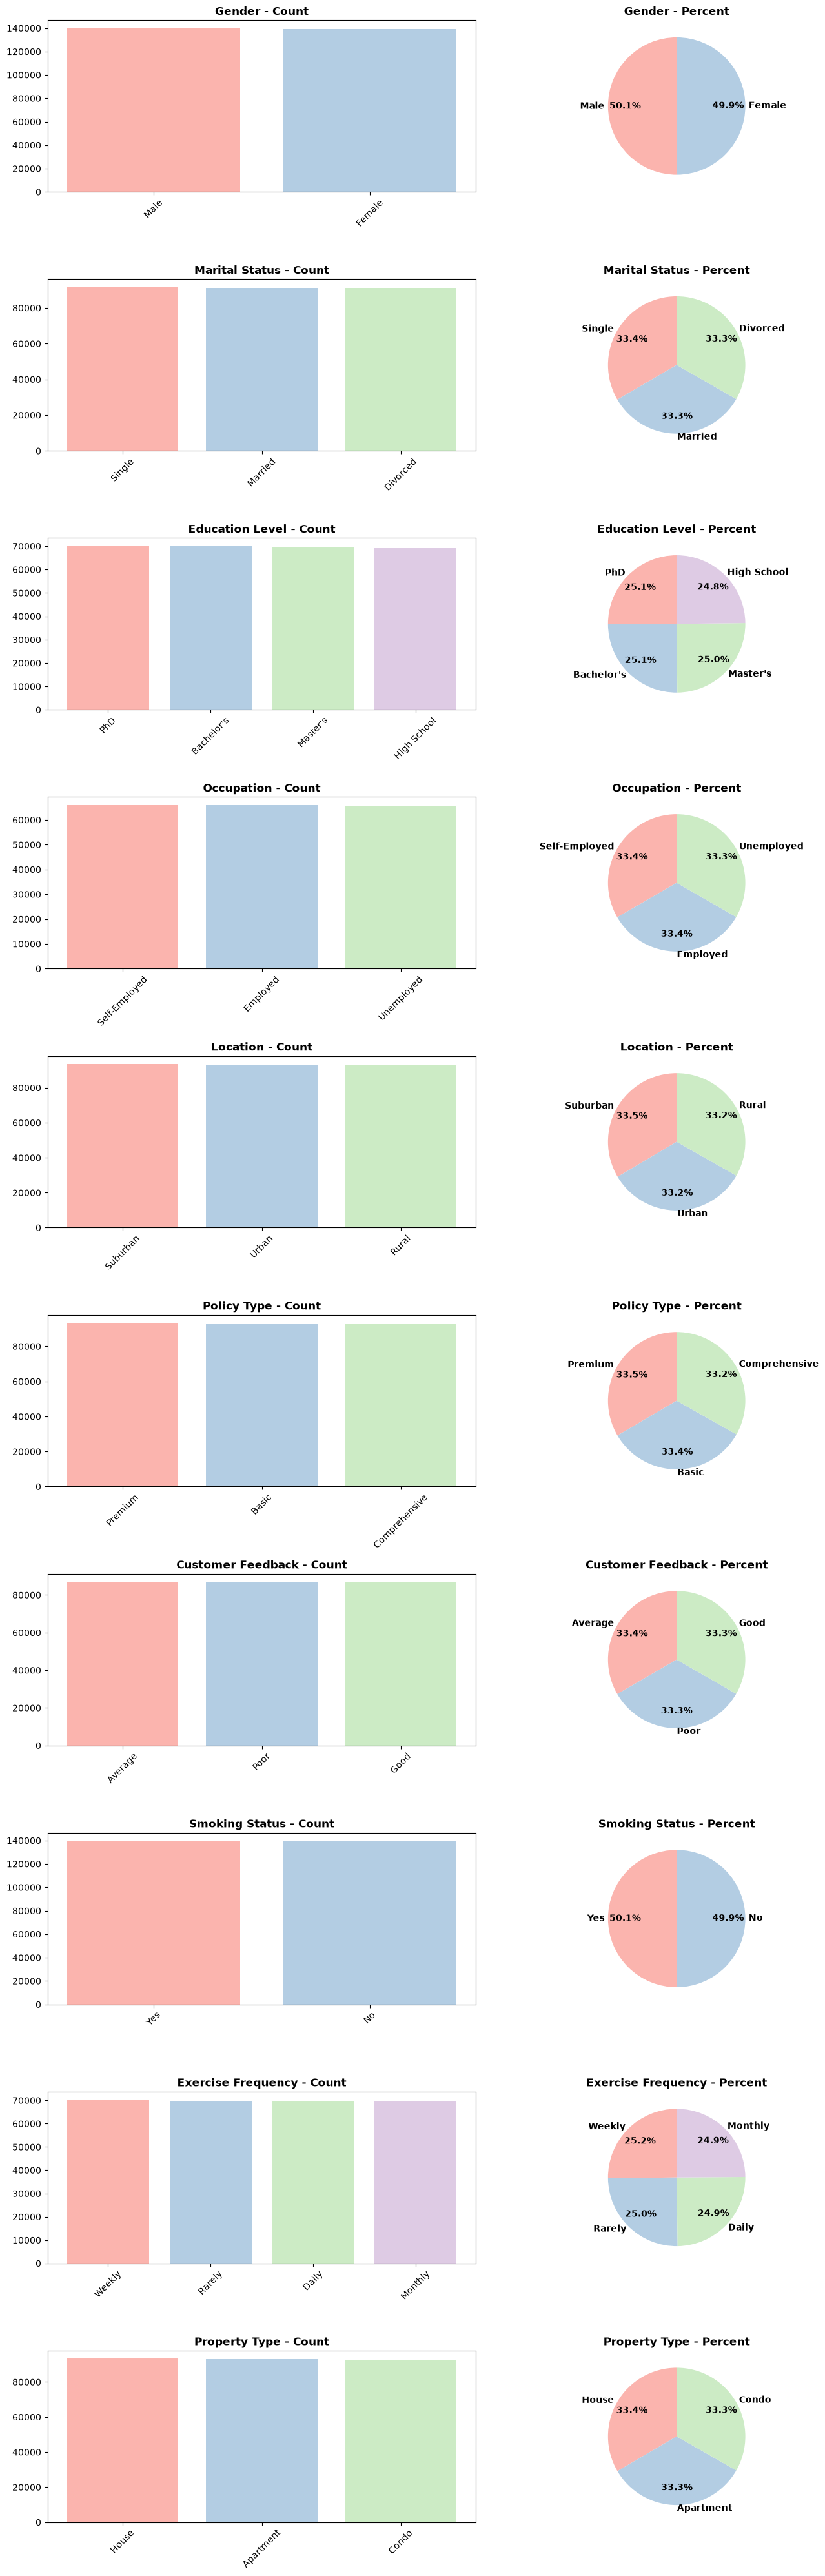

In [12]:
n = len(categorical)

fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n), squeeze=False)

for i, var in enumerate(categorical):
    counts = df[var].value_counts()
    # example :      male  : count1
    #                female: count2

    axes[i, 0].bar(
        counts.index.astype(str),  # label
        counts.values,             # counts
        color=plt.cm.Pastel1.colors
    )
    axes[i, 0].set_title(
        f'{var.replace("_", " ").title()} - Count',
        weight='bold'
    )
    axes[i, 0].tick_params(axis='x', rotation=45)

    axes[i, 1].pie(
        counts,
        labels=counts.index.astype(str),
        autopct='%1.1f%%',
        labeldistance=1.05,
        pctdistance=0.75,
        textprops={'fontsize': 10, 'fontweight': 'bold'},
        colors=plt.cm.Pastel1.colors,
        startangle=90
    )
    axes[i, 1].set_title(
        f'{var.replace("_", " ").title()} - Percent',
        weight='bold'
    )

plt.tight_layout()
plt.show()

**Distribution Analysis of Numerical Variables**

/tmp/ipykernel_25376/1785613087.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = axes[i, 1].boxplot(data,
/tmp/ipykernel_25376/1785613087.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = axes[i, 1].boxplot(data,
/tmp/ipykernel_25376/1785613087.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = axes[i, 1].boxplot(data,
/tmp/ipykernel_25376/1785613087.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = axes[i, 1].boxplot(data,
/tmp/ipykernel_25376/1785613087.py:27: MatplotlibDeprecationWarning: vert: bool was depr

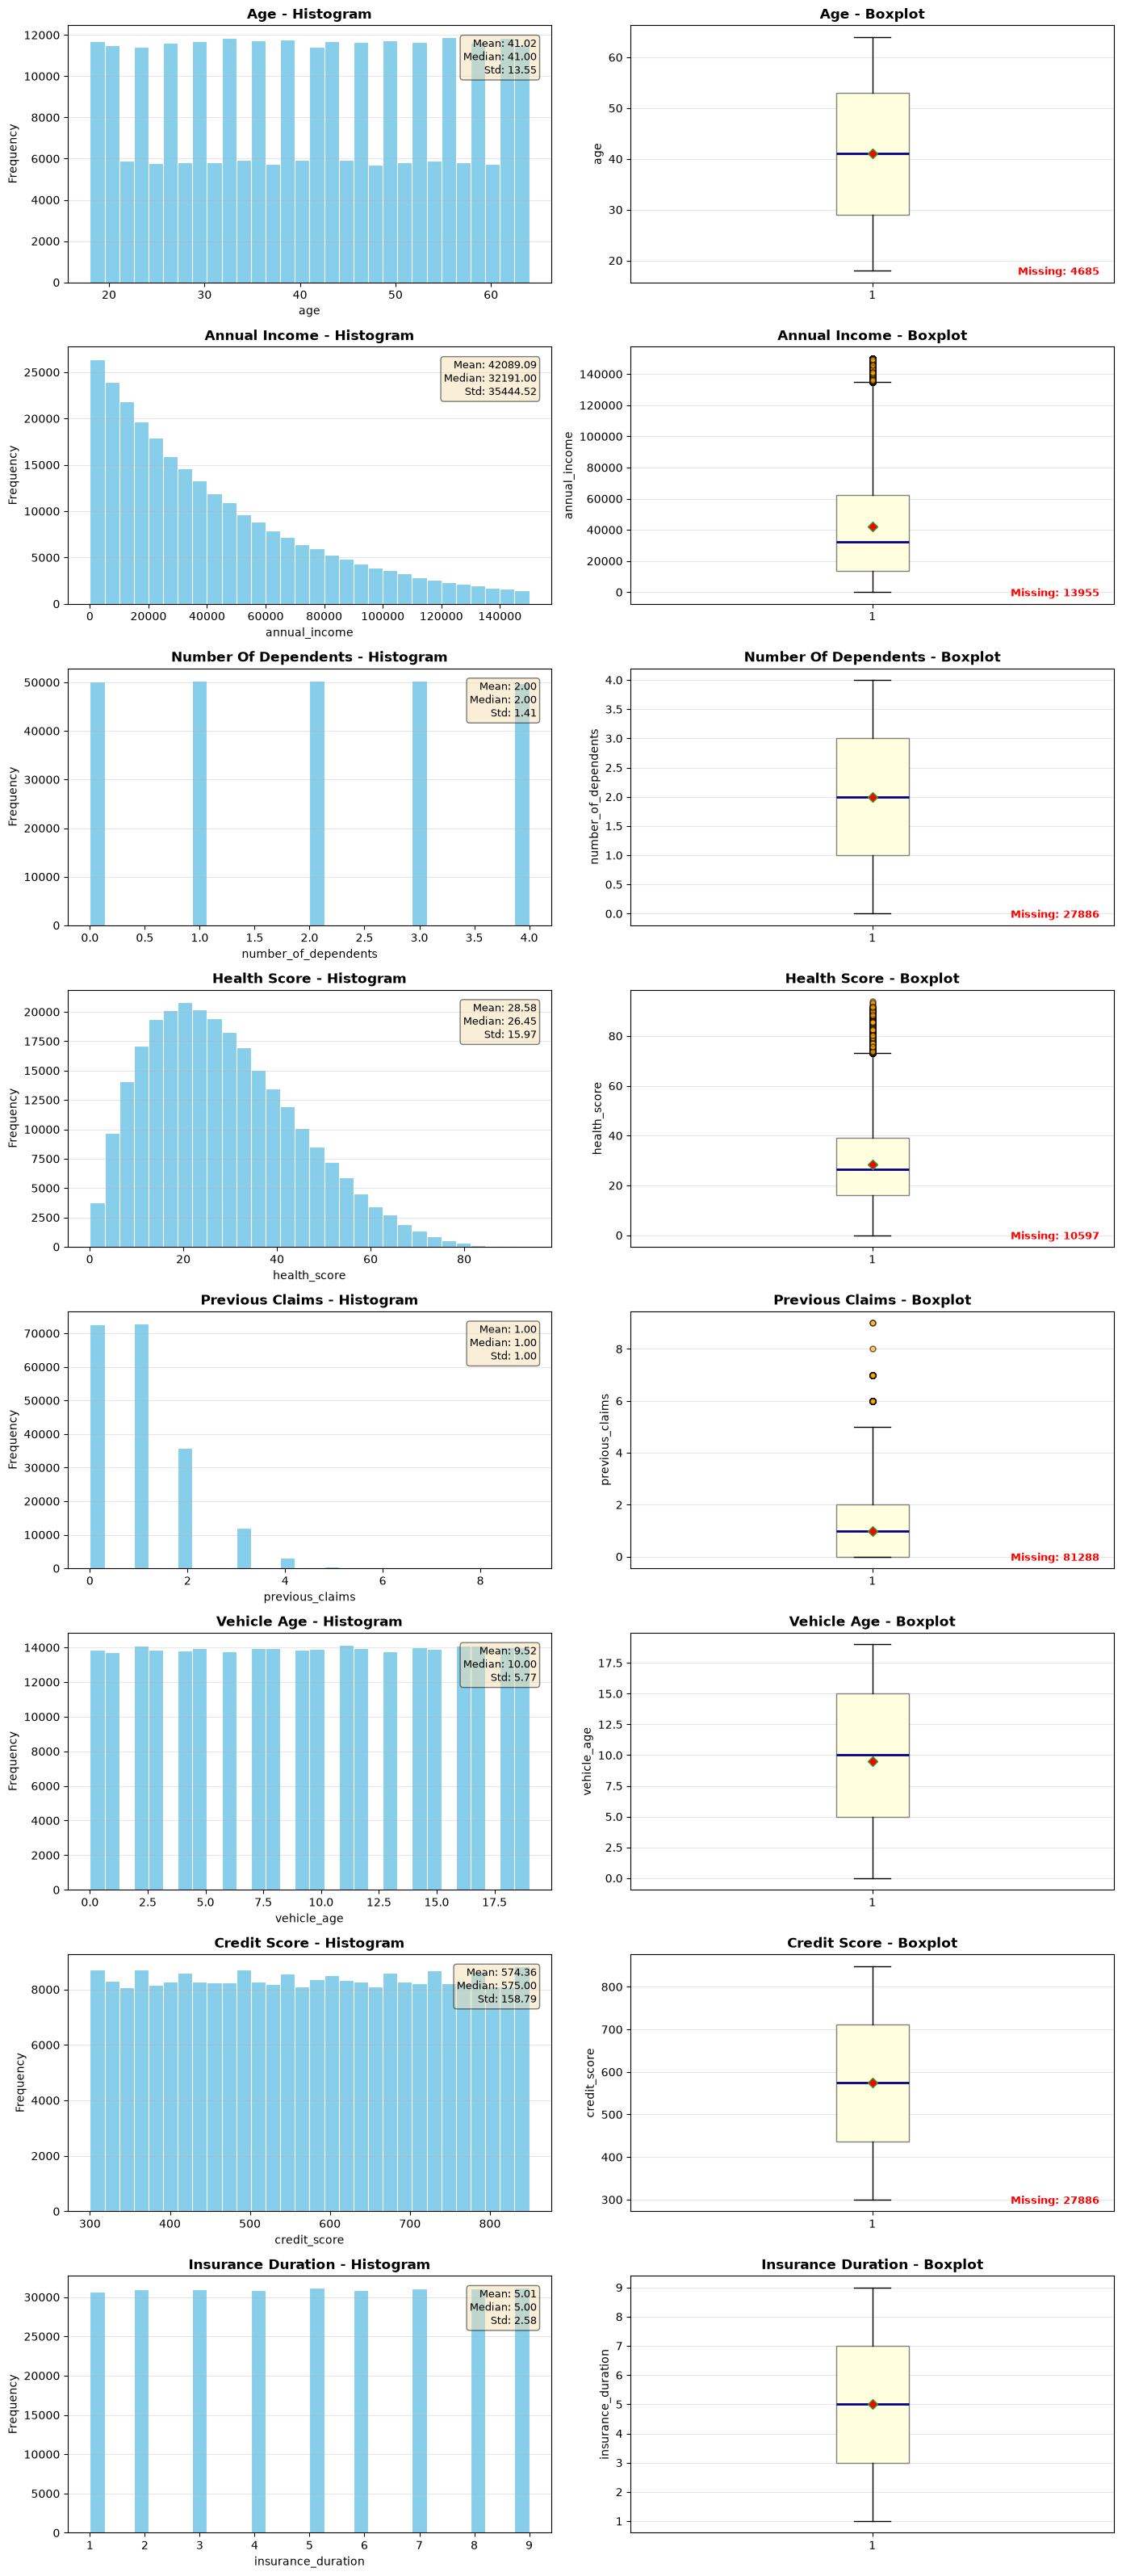

In [13]:
fig, axes = plt.subplots(len(numerical), 2, figsize = (14, 4 * len(numerical)), squeeze=False)
for i, var in enumerate(numerical):
    # histogram
    data = df[var].dropna()
    axes[i, 0].hist(data,
                    color = 'skyblue',
                    bins = 30,
                    edgecolor='white', # ranh gioi mau trang
                    linewidth=0.8)
    axes[i, 0].set_title(
        f'{var.replace("_", " ").title()} - Histogram',
        weight='bold'
    )
    axes[i,0].set_xlabel(var)
    axes[i,0].set_ylabel('Frequency')
    axes[i,0].grid(axis='y', alpha=0.3) # luoi
    # some discription statistic
    stats_text = f'Mean: {data.mean():.2f}\nMedian: {data.median():.2f}\nStd: {data .std():.2f}'
    axes[i,0].text(0.97, 0.95, stats_text,
                   transform=axes[i,0].transAxes,
                   fontsize=9, verticalalignment='top', # location in plot (ver)
                   horizontalalignment='right', #(horizon)
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

    
    # boxplot
    bp = axes[i, 1].boxplot(data,
                       vert=True,
                       patch_artist=True,  # cho phep fill mau
                       showmeans=True,     # hien thi mean
                       meanprops=dict(marker='D', markerfacecolor='red', markersize=6),
                       medianprops=dict(color='darkblue', linewidth=2),
                       flierprops=dict(marker='o', markerfacecolor='orange', 
                       markersize=5, alpha=0.6))
    bp['boxes'][0].set_facecolor('lightyellow')
    bp['boxes'][0].set_edgecolor('gray')
    axes[i, 1].set_title(f'{var.replace("_", " ").title()} - Boxplot', weight='bold')
    axes[i, 1].set_ylabel(var)
    axes[i, 1].grid(axis='y', alpha=0.3)


    # note missing values per plot
    n_missing = df[var].isnull().sum()
    if n_missing > 0:
        axes[i, 1].text(0.97, 0.02, f'Missing: {n_missing}',
                        transform=axes[i, 1].transAxes,
                        fontsize=9, ha='right', va='bottom',
                        color='red', fontweight='bold')
        
plt.tight_layout()
plt.show()

**age, insurance_duration, vehicle_age, number_of_dependents**
- describe()

In [14]:
print('Discriptive Statistic:')
print(df[['age', 'insurance_duration', 'vehicle_age', 'number_of_dependents']].describe())

Discriptive Statistic:
                 age  insurance_duration    vehicle_age  number_of_dependents
count  274175.000000       278860.000000  278860.000000         250974.000000
mean       41.020771            5.007764       9.520283              1.998048
std        13.549683            2.581349       5.767915              1.412312
min        18.000000            1.000000       0.000000              0.000000
25%        29.000000            3.000000       5.000000              1.000000
50%        41.000000            5.000000      10.000000              2.000000
75%        53.000000            7.000000      15.000000              3.000000
max        64.000000            9.000000      19.000000              4.000000


**credit_score, healthy_score**

In [15]:
print('Discriptive Statistic:')
print(df[['credit_score', 'health_score']].describe())

Discriptive Statistic:
        credit_score   health_score
count  250974.000000  268263.000000
mean      574.362049      28.584290
std       158.792037      15.966208
min       300.000000       0.035436
25%       437.000000      16.149890
50%       575.000000      26.451244
75%       712.000000      38.966369
max       849.000000      93.876090


In [16]:
print('Discriptive Statistic:')
print(df[['annual_income','previous_claims']].describe())

Discriptive Statistic:
       annual_income  previous_claims
count  264905.000000    197572.000000
mean    42089.085329         0.998117
std     35444.517255         1.000795
min         0.000000         0.000000
25%     13588.000000         0.000000
50%     32191.000000         1.000000
75%     62164.000000         2.000000
max    149997.000000         9.000000


**Analyzing the Target Variable - premium_amount**

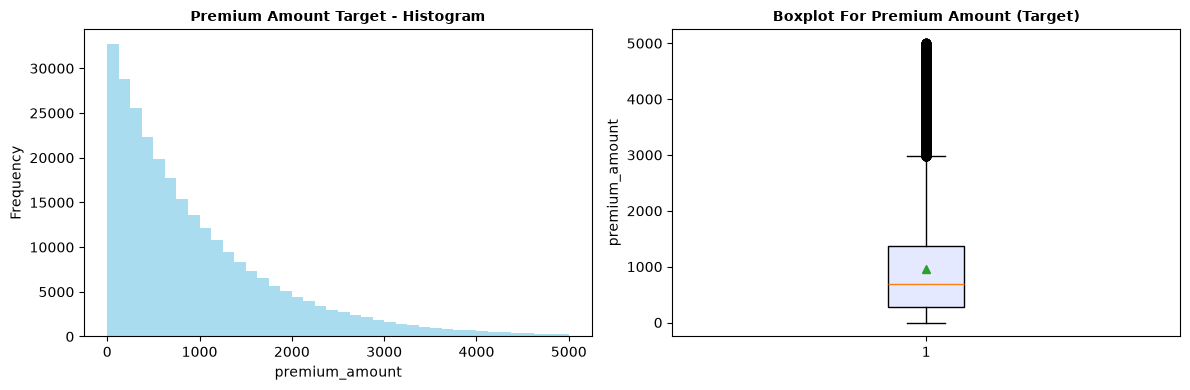

In [17]:
fig, axes = plt.subplots(1, 2, figsize = (12,4))
axes[0].hist(df['premium_amount'].dropna(),
               bins = 40,
               color = 'skyblue',
               alpha = 0.7)
axes[0].set_title('Premium Amount Target - Histogram', fontsize = 10, weight = 'bold')
axes[0].set_xlabel('premium_amount')
axes[0].set_ylabel('Frequency')


axes[1].boxplot(df['premium_amount'].dropna(),
                showmeans = True,
                patch_artist=True,
                boxprops=dict(facecolor="#e5e9ff"))
axes[1].set_title('Boxplot For Premium Amount (Target)', weight = 'bold', fontsize = 10)
axes[1].set_ylabel('premium_amount')

plt.tight_layout()
plt.show()


In [18]:
print('Target of Premium Amount')
print(df['premium_amount'].describe())

Target of Premium Amount
count    277019.000000
mean        966.118667
std         909.404567
min           0.000000
25%         286.000000
50%         688.000000
75%        1367.000000
max        4999.000000
Name: premium_amount, dtype: float64


**Missing Value**

In [19]:
miss_count = df.isna().sum()
miss_percent = round((miss_count / len(df) * 100), 2)

miss_summary = pd.DataFrame({
    'miss_count' : miss_count,
    'miss_percent' : miss_percent
})
miss_summary

,miss_count,miss_percent
age,4685,1.68
gender,0,0.00
annual_income,13955,5.00
marital_status,5019,1.80
number_of_dependents,27886,10.00
education_level,0,0.00
occupation,81288,29.15
health_score,10597,3.80
location,0,0.00
policy_type,0,0.00


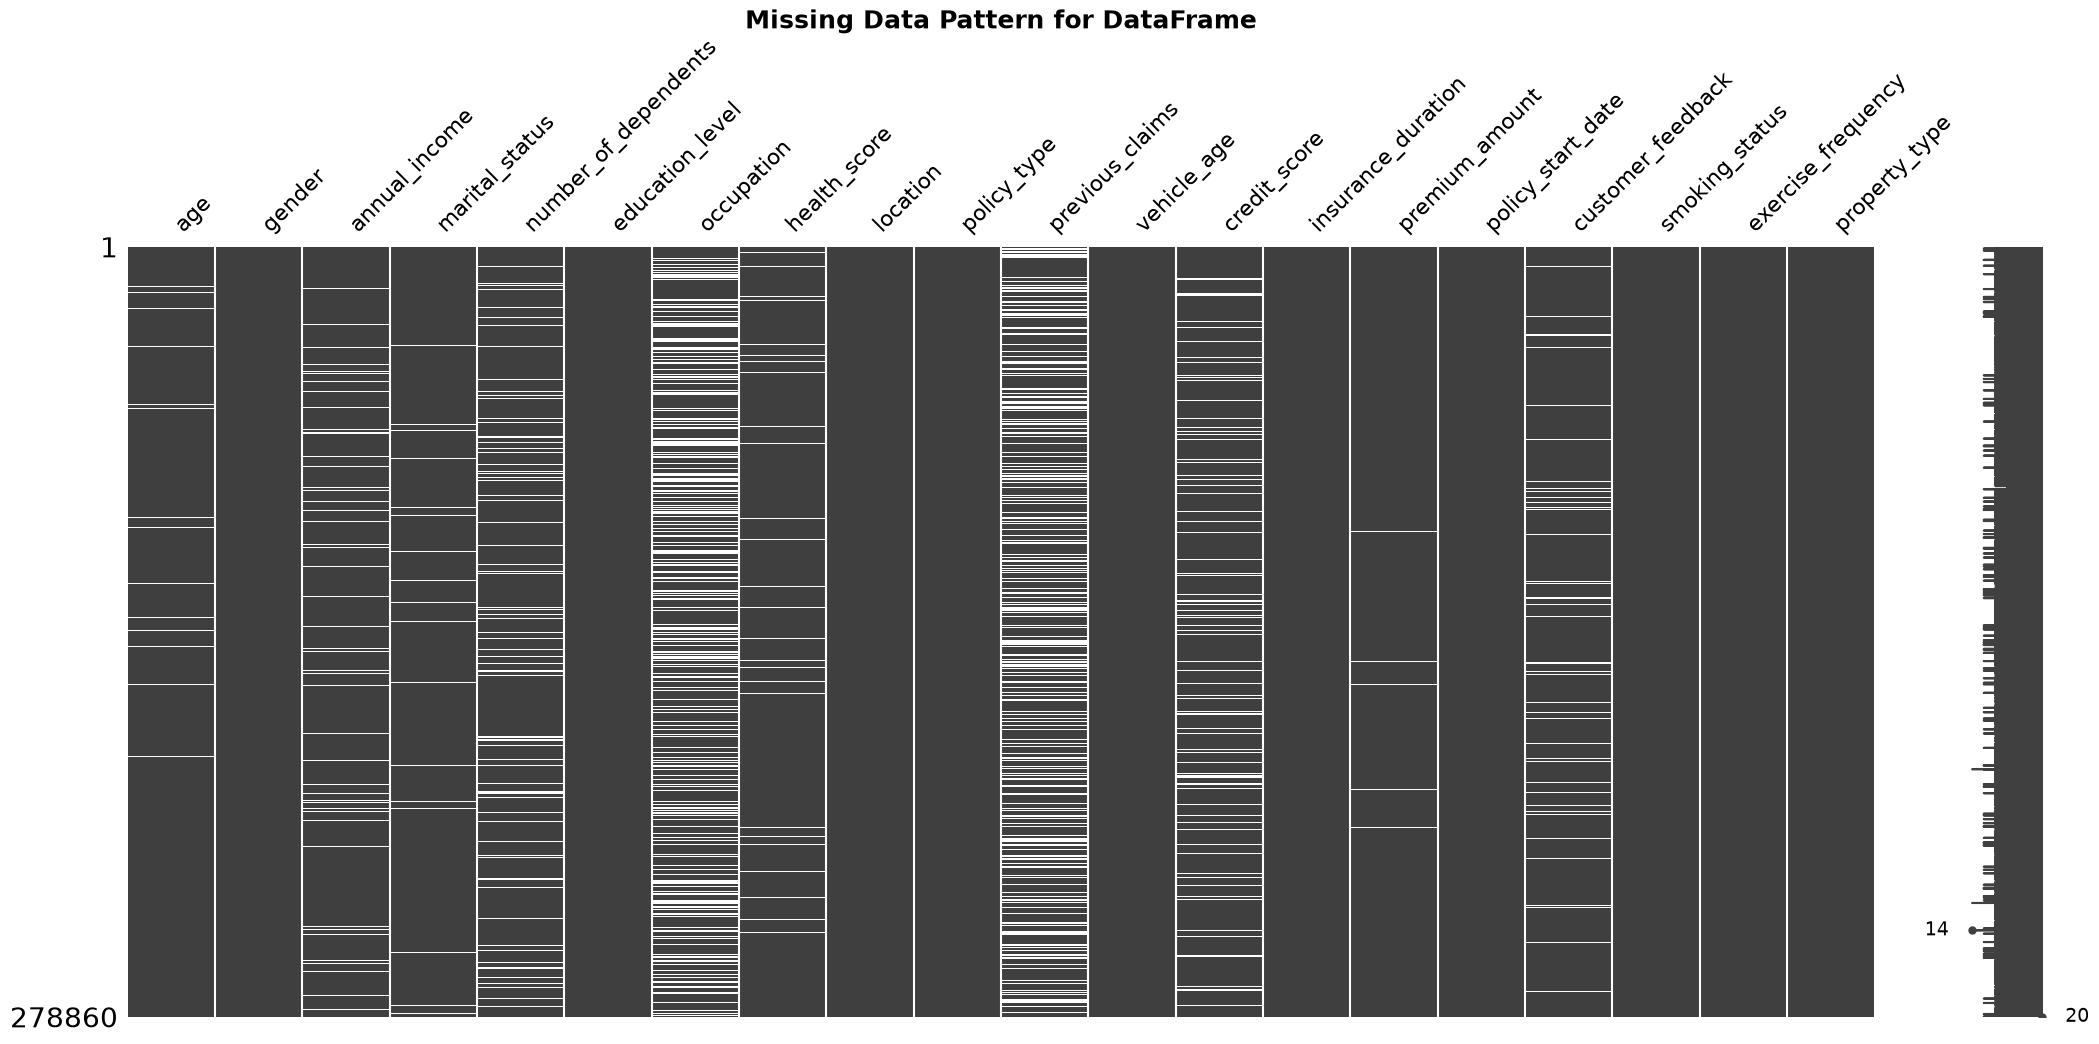

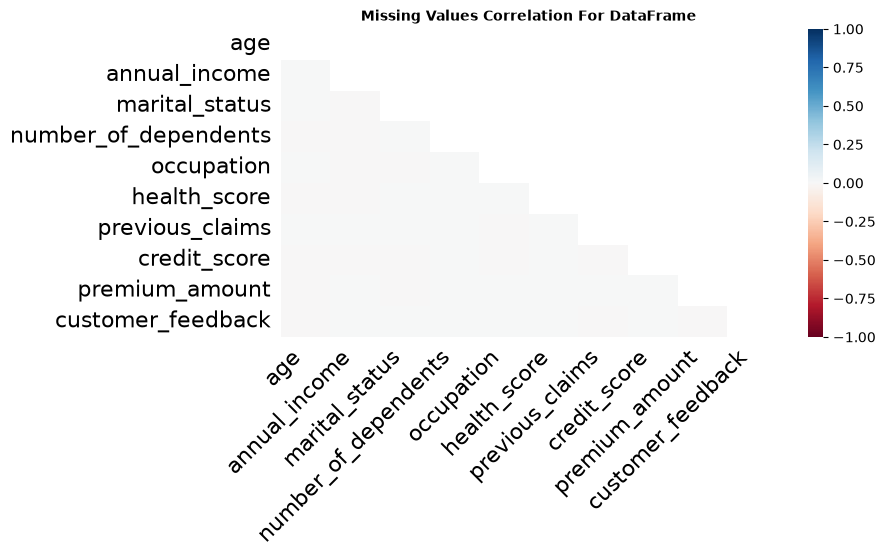

In [20]:
# visualize missing data parterns
msno.matrix(df)
plt.title('Missing Data Pattern for DataFrame', size = 18, weight = 'bold')
plt.show()

msno.heatmap(df, figsize=(8,4))
plt.title('Missing Values Correlation For DataFrame', size = 10, weight = 'bold')
plt.show()


- ta thay cac bien mau nhat
- => doc lap missing voi nhau doi mot
- neu nghieng ve phia 1 thi no co xu huong, missing cung hang voi nhau => co moi tuong quan manh
- 0 thi dang doc lap voi nhau (truong hop dang gap)
- nghieng ve -1 thi neu bien A co xu huong missing nhieu thi bien B se co xu huong day du
- **Chien Luoc Xu Ly Missing Value o day ta su dung impute/flag từng biến độc lập**

**Evaluating Premium Amount Trends By Various Factors**

**Premium Amount By Property, Policy Type, and Location**

In [21]:
def boxplot(var):
    plt.figure(figsize=(8,4))
    sns.boxplot(data = df, x = var, y = 'premium_amount', palette='Set2')
    plt.title(f'Boxplot of {var} vs premium_amount', size = 12, weight = 'bold')

/tmp/ipykernel_25376/1792124523.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = var, y = 'premium_amount', palette='Set2')


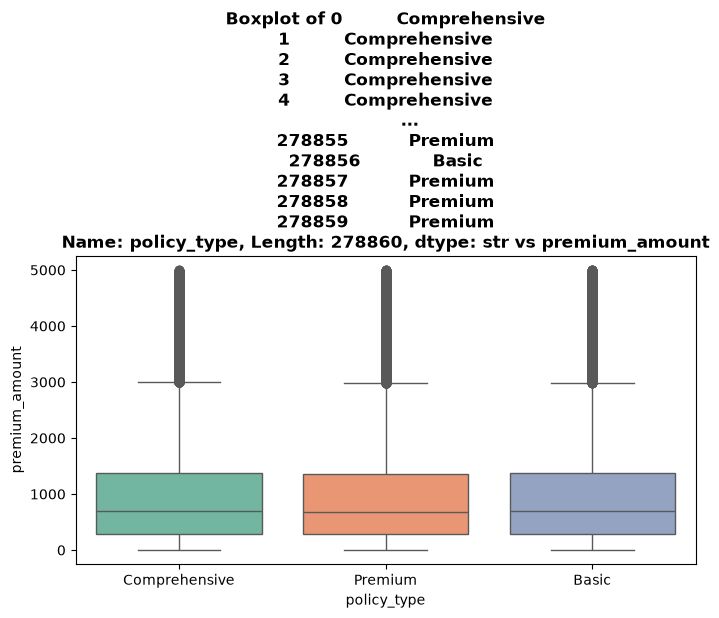

In [22]:
boxplot(df['policy_type'])

In [23]:
df.groupby('policy_type')['premium_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
policy_type,,,,,,,,
Basic,92439.0,967.252621,910.563361,0.0,285.0,690.0,1367.0,4999.0
Comprehensive,91899.0,967.590104,910.682719,0.0,286.0,689.0,1369.0,4997.0
Premium,92681.0,963.528652,906.980812,0.0,286.0,685.0,1364.0,4999.0


/tmp/ipykernel_25376/1792124523.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = var, y = 'premium_amount', palette='Set2')


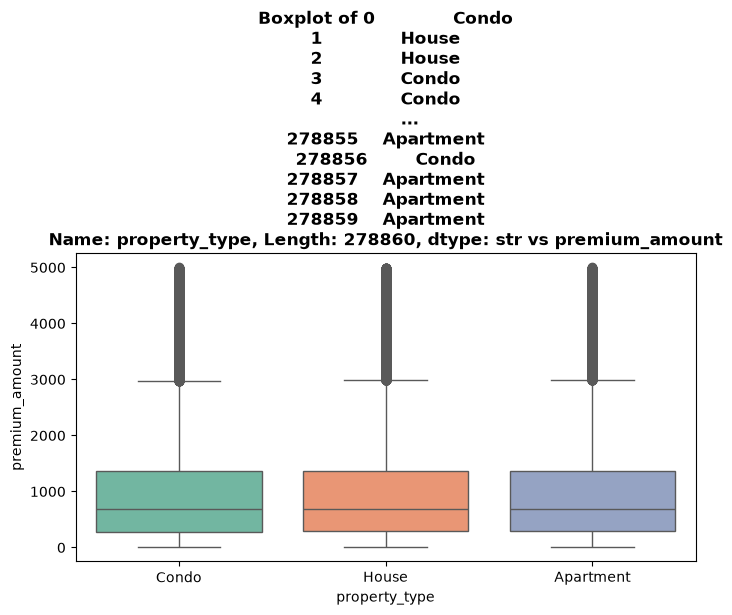

In [24]:
boxplot(df['property_type'])

In [25]:
df.groupby('property_type')['premium_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
property_type,,,,,,,,
Apartment,92268.0,967.662440,910.526761,0.0,285.75,691.0,1369.0,4999.0
Condo,92118.0,964.034011,909.268308,0.0,285.00,684.0,1362.0,4999.0
House,92633.0,966.654043,908.427049,0.0,288.00,689.0,1368.0,4997.0


/tmp/ipykernel_25376/1792124523.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = var, y = 'premium_amount', palette='Set2')


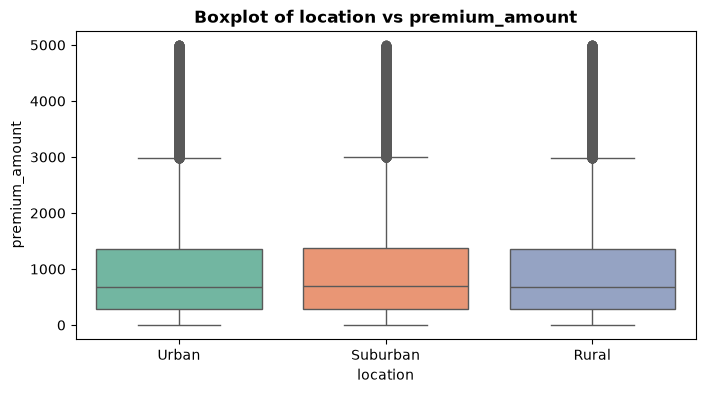

In [26]:
boxplot('location')

In [27]:
df.groupby('location')['premium_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
location,,,,,,,,
Rural,92036.0,966.011354,912.423220,0.0,285.0,686.0,1365.0,4997.0
Suburban,92873.0,965.407966,905.653692,0.0,286.0,691.0,1369.0,4999.0
Urban,92110.0,966.942482,910.166374,0.0,287.0,688.0,1366.0,4999.0


**Premium Amount By year**

In [28]:
df['year'] = df['policy_start_date'].dt.year
df['month'] = df['policy_start_date'].dt.month

/tmp/ipykernel_25376/1792124523.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = var, y = 'premium_amount', palette='Set2')


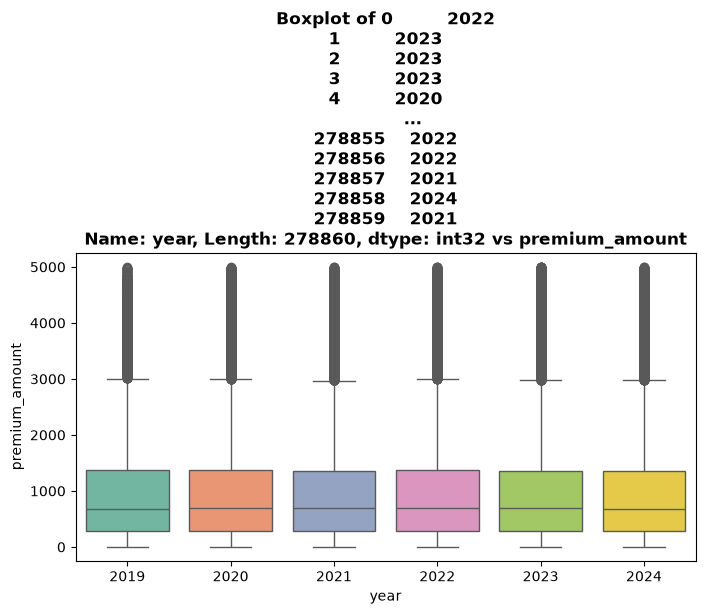

In [29]:
boxplot(df['year'])

In [30]:
df.groupby('year')['premium_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2019,20597.0,966.305870,917.470556,0.0,280.0,682.0,1371.0,4993.0
2020,55297.0,971.730094,912.892574,0.0,289.0,692.0,1373.0,4996.0
2021,55751.0,961.915105,906.080548,0.0,285.0,687.0,1359.5,4997.0
2022,55577.0,968.008097,909.033931,0.0,287.0,692.0,1374.0,4999.0
2023,54948.0,966.366565,909.504850,0.0,287.0,687.0,1363.0,4999.0
2024,34849.0,960.424718,904.801390,0.0,282.0,684.0,1360.0,4998.0


/tmp/ipykernel_25376/1792124523.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = var, y = 'premium_amount', palette='Set2')


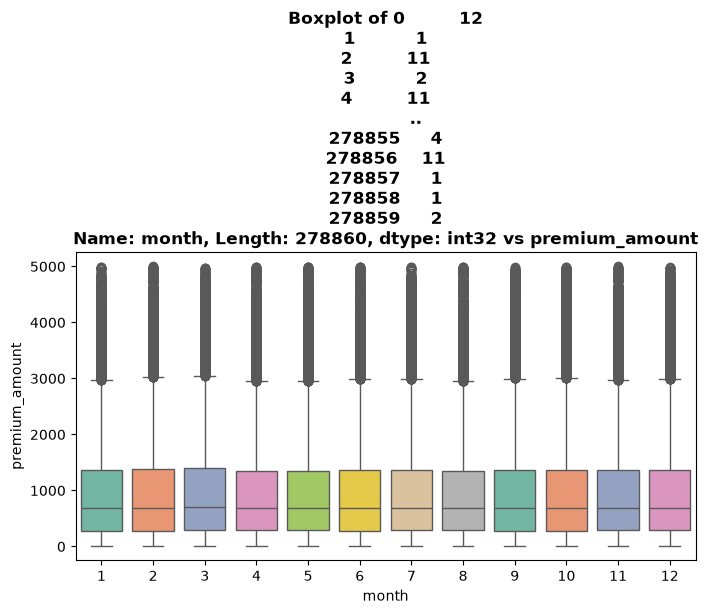

In [31]:
boxplot(df['month'])

In [32]:
df.groupby('month')['premium_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
month,,,,,,,,
1,23358.0,961.722279,906.945213,0.0,280.0,681.0,1358.00,4987.0
2,21629.0,970.733044,913.326974,0.0,285.0,685.0,1382.00,4999.0
3,23481.0,979.916102,910.820266,0.0,290.0,710.0,1394.00,4978.0
4,23067.0,966.299259,907.607206,0.0,289.0,691.0,1356.00,4994.0
5,23840.0,959.068960,906.212270,0.0,289.0,680.0,1353.25,4997.0
6,22688.0,960.376190,905.236815,0.0,283.0,681.0,1364.00,4992.0
7,23334.0,961.134996,898.471263,0.0,286.0,689.0,1365.00,4987.0
8,23535.0,959.480603,904.848984,0.0,287.0,681.0,1351.00,4996.0
9,22669.0,967.420045,920.703324,0.0,280.0,681.0,1369.00,4993.0


**Premium Amount By Previous Claims**

/tmp/ipykernel_25376/1792124523.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = var, y = 'premium_amount', palette='Set2')


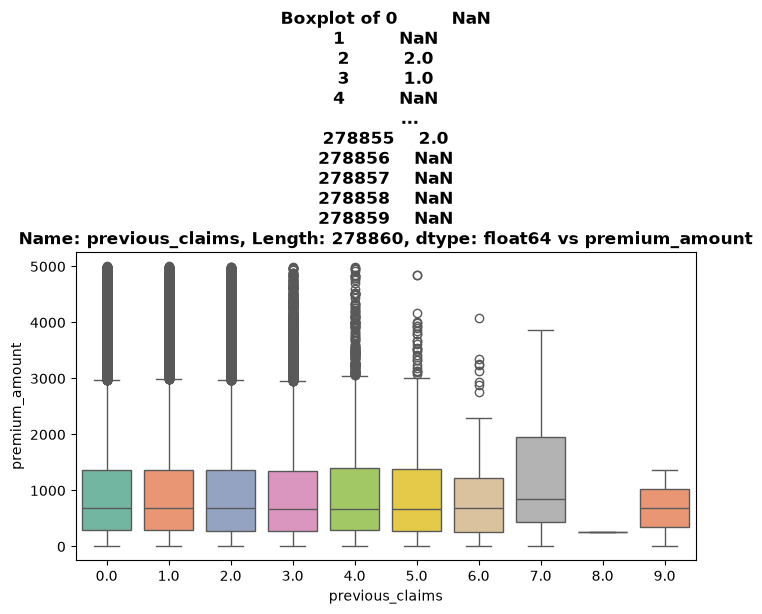

In [33]:
boxplot(df['previous_claims'])

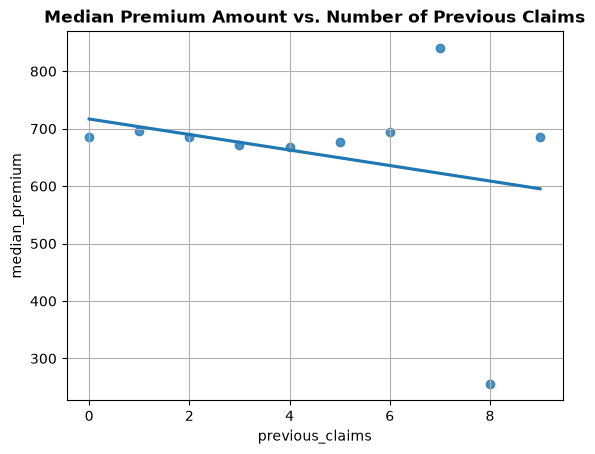

In [34]:
# Calculate medians for premium amounts grouped by previous_claims 
median_values = df.groupby('previous_claims')['premium_amount'].median().reset_index()

data = {'previous_claims': median_values['previous_claims'].tolist(), 
        'median_premium': median_values['premium_amount'].tolist()}

df_data = pd.DataFrame(data)
sns.regplot(data=df_data, x = 'previous_claims', y = 'median_premium', ci = None)
plt.title('Median Premium Amount vs. Number of Previous Claims', 
          fontsize=12, weight='bold') 
plt.grid(True)
plt.show()

**Permium Amount By Occupation**

In [35]:
df.groupby('occupation')['premium_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
occupation,,,,,,,,
Employed,65459.0,966.184986,903.141004,0.0,288.0,693.0,1372.5,4997.0
Self-Employed,65479.0,965.859833,909.908723,0.0,285.0,688.0,1366.0,4999.0
Unemployed,65333.0,967.047143,910.713157,0.0,286.0,688.0,1364.0,4996.0


/tmp/ipykernel_25376/1792124523.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = var, y = 'premium_amount', palette='Set2')


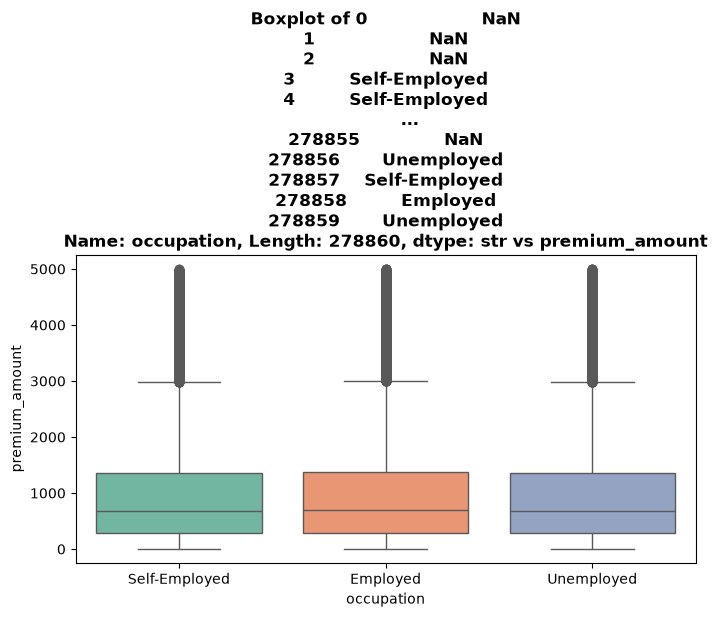

In [36]:
boxplot(df['occupation'])

**Most Common Occupation by ['education_level', 'income_bin', 'gender']**

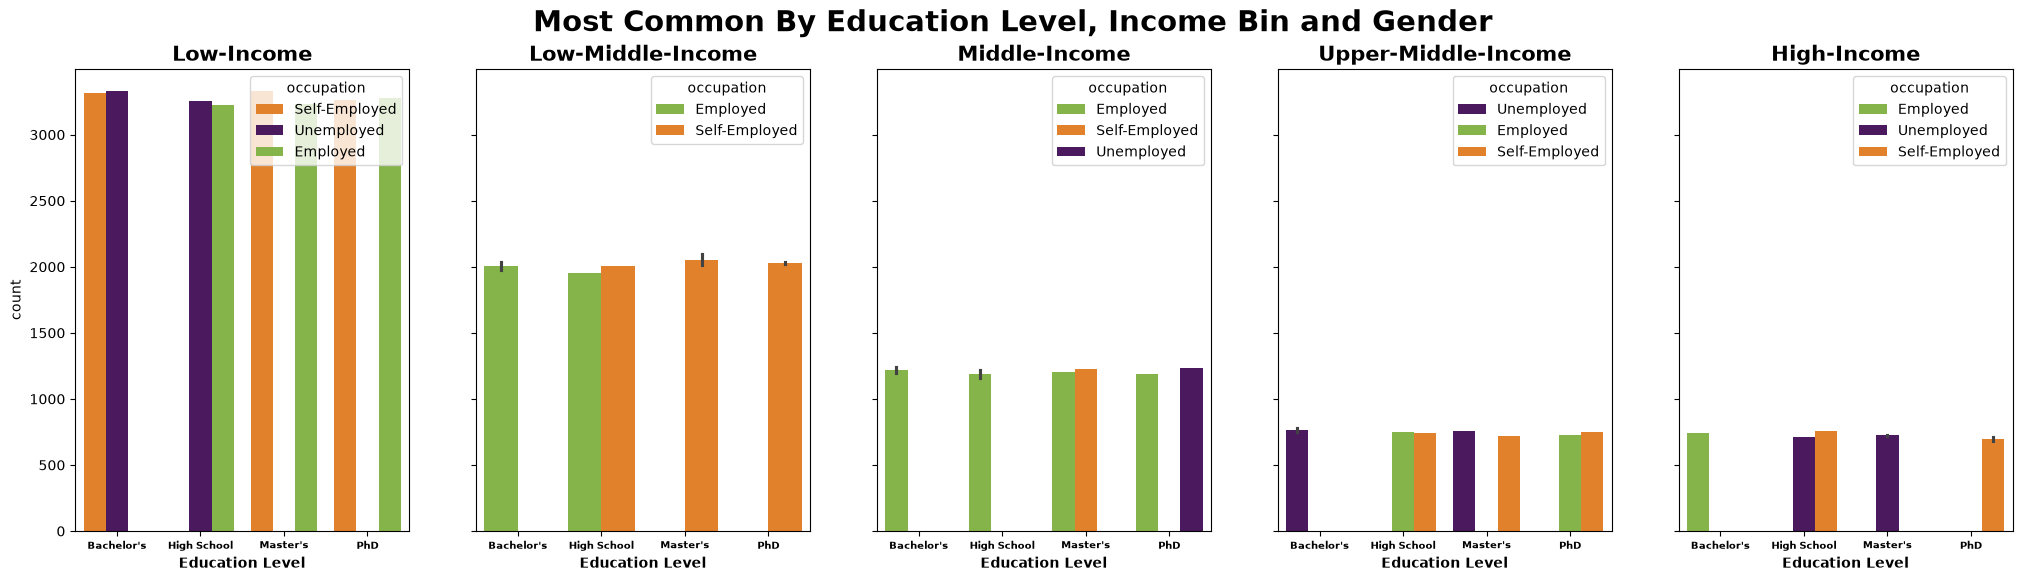

In [37]:
income_bins = [0, 25000, 50000, 75000, 100000, float('inf')]
income_labels = ['Low', 'Low-Middle', 'Middle', 'Upper-Middle', 'High']

occupation_palette = { 'Employed': "#87c53a", 'Self-Employed': '#ff7f0e', 'Unemployed': "#500f69"}

# use pd.cut(df, bins=, labels =) to create income_bin feature
df['income_bin'] = pd.cut(df['annual_income'],
                          bins = income_bins,
                          labels=income_labels,
                          include_lowest=True)

# find occupation by ['education_level', 'income_bin', 'gender'] 
occupation_counts = df.groupby(['education_level', 'income_bin', 'gender'])['occupation'].value_counts().reset_index()

# find most common occupation by ['education_level', 'income_bin', 'gender']
occupation_mode = occupation_counts.loc[
    occupation_counts.groupby(['education_level', 'income_bin', 'gender'])['count'].idxmax()
]

income_label = occupation_mode['income_bin'].unique()

### dung sns de ve barplot de hon ###
# sns.barplot(
#     data=income_low_oc,
#     x='education_level',
#     y='count',
#     hue='occupation'
#     )
# plt.title('Low Income')
# plt.show()

fig, axes = plt.subplots(1,5,figsize=(25,6),sharey=True) # dung chung cot y
fig.suptitle('Most Common By Education Level, Income Bin and Gender', fontsize = 21, weight='bold')
for idx, level in enumerate(income_labels):
    data = occupation_mode[occupation_mode['income_bin']==level]
    ax = axes[idx]
    sns.barplot(
        data=data,
        x='education_level',
        y='count',
        hue='occupation',
        palette=occupation_palette,
        ax=ax,
        dodge=True
    )
    ax.set_title(f'{level}-Income', weight='bold', size = 15)
    ax.set_xlabel('Education Level', fontdict=dict(weight='bold'))

    # set the x-axis labels in bold
    for label in ax.get_xticklabels():
        label.set_weight('bold')
        label.set_size(7)
plt.show()
    

In [38]:
df.head()

,age,gender,annual_income,marital_status,number_of_dependents,education_level,occupation,health_score,location,policy_type,...,insurance_duration,premium_amount,policy_start_date,customer_feedback,smoking_status,exercise_frequency,property_type,year,month,income_bin
0,56.0,Male,99990.0,Married,1.0,Master's,NaN,31.074627,Urban,Comprehensive,...,5,308.0,2022-12-10 15:21:39.078837,Poor,Yes,Daily,Condo,2022,12,Upper-Middle
1,46.0,Male,2867.0,Single,1.0,Bachelor's,NaN,50.271335,Urban,Comprehensive,...,4,517.0,2023-01-31 15:21:39.078837,Good,Yes,Monthly,House,2023,1,Low
2,32.0,Female,30154.0,Divorced,3.0,Bachelor's,NaN,14.714909,Suburban,Comprehensive,...,8,849.0,2023-11-26 15:21:39.078837,Poor,No,Monthly,House,2023,11,Low-Middle
3,60.0,Female,48371.0,Divorced,0.0,PhD,Self-Employed,25.346926,Rural,Comprehensive,...,7,927.0,2023-02-27 15:21:39.078837,Poor,No,Rarely,Condo,2023,2,Low-Middle
4,25.0,Female,54174.0,Divorced,0.0,High School,Self-Employed,6.659499,Urban,Comprehensive,...,8,303.0,2020-11-25 15:21:39.078837,Poor,No,Rarely,Condo,2020,11,Middle
